RMSE: 0.041835897776980456
R^2: 0.9716465768593229


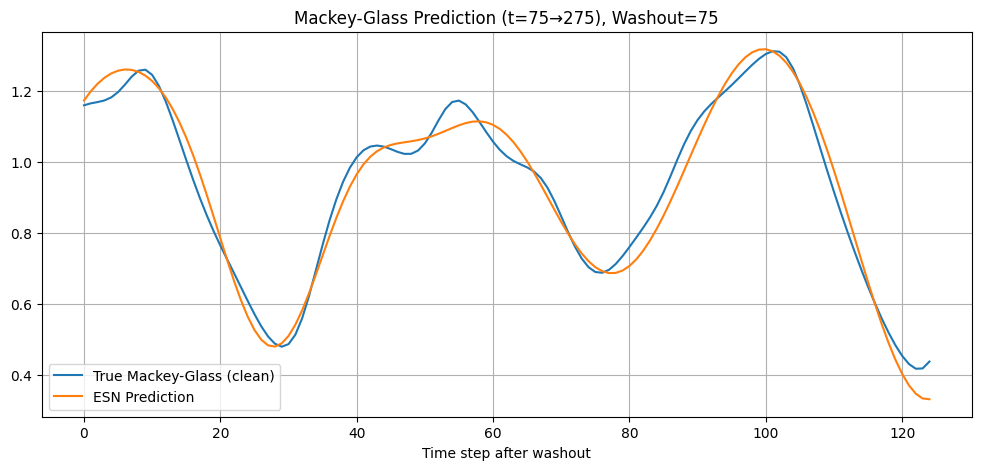

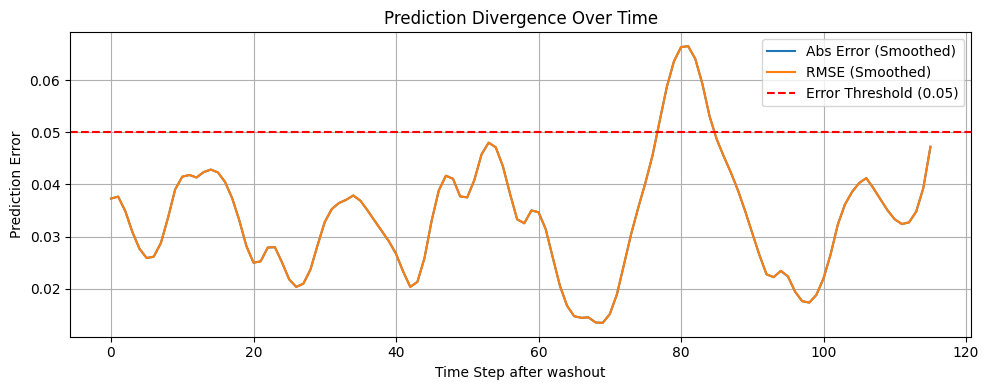

No sustained divergence above threshold 0.05 for 10 steps detected.

F-statistic: 2090.4157
P-value: 1.1102e-16
The model's predictions are statistically significant (p < 0.05).

Total runtime: 14.54 seconds


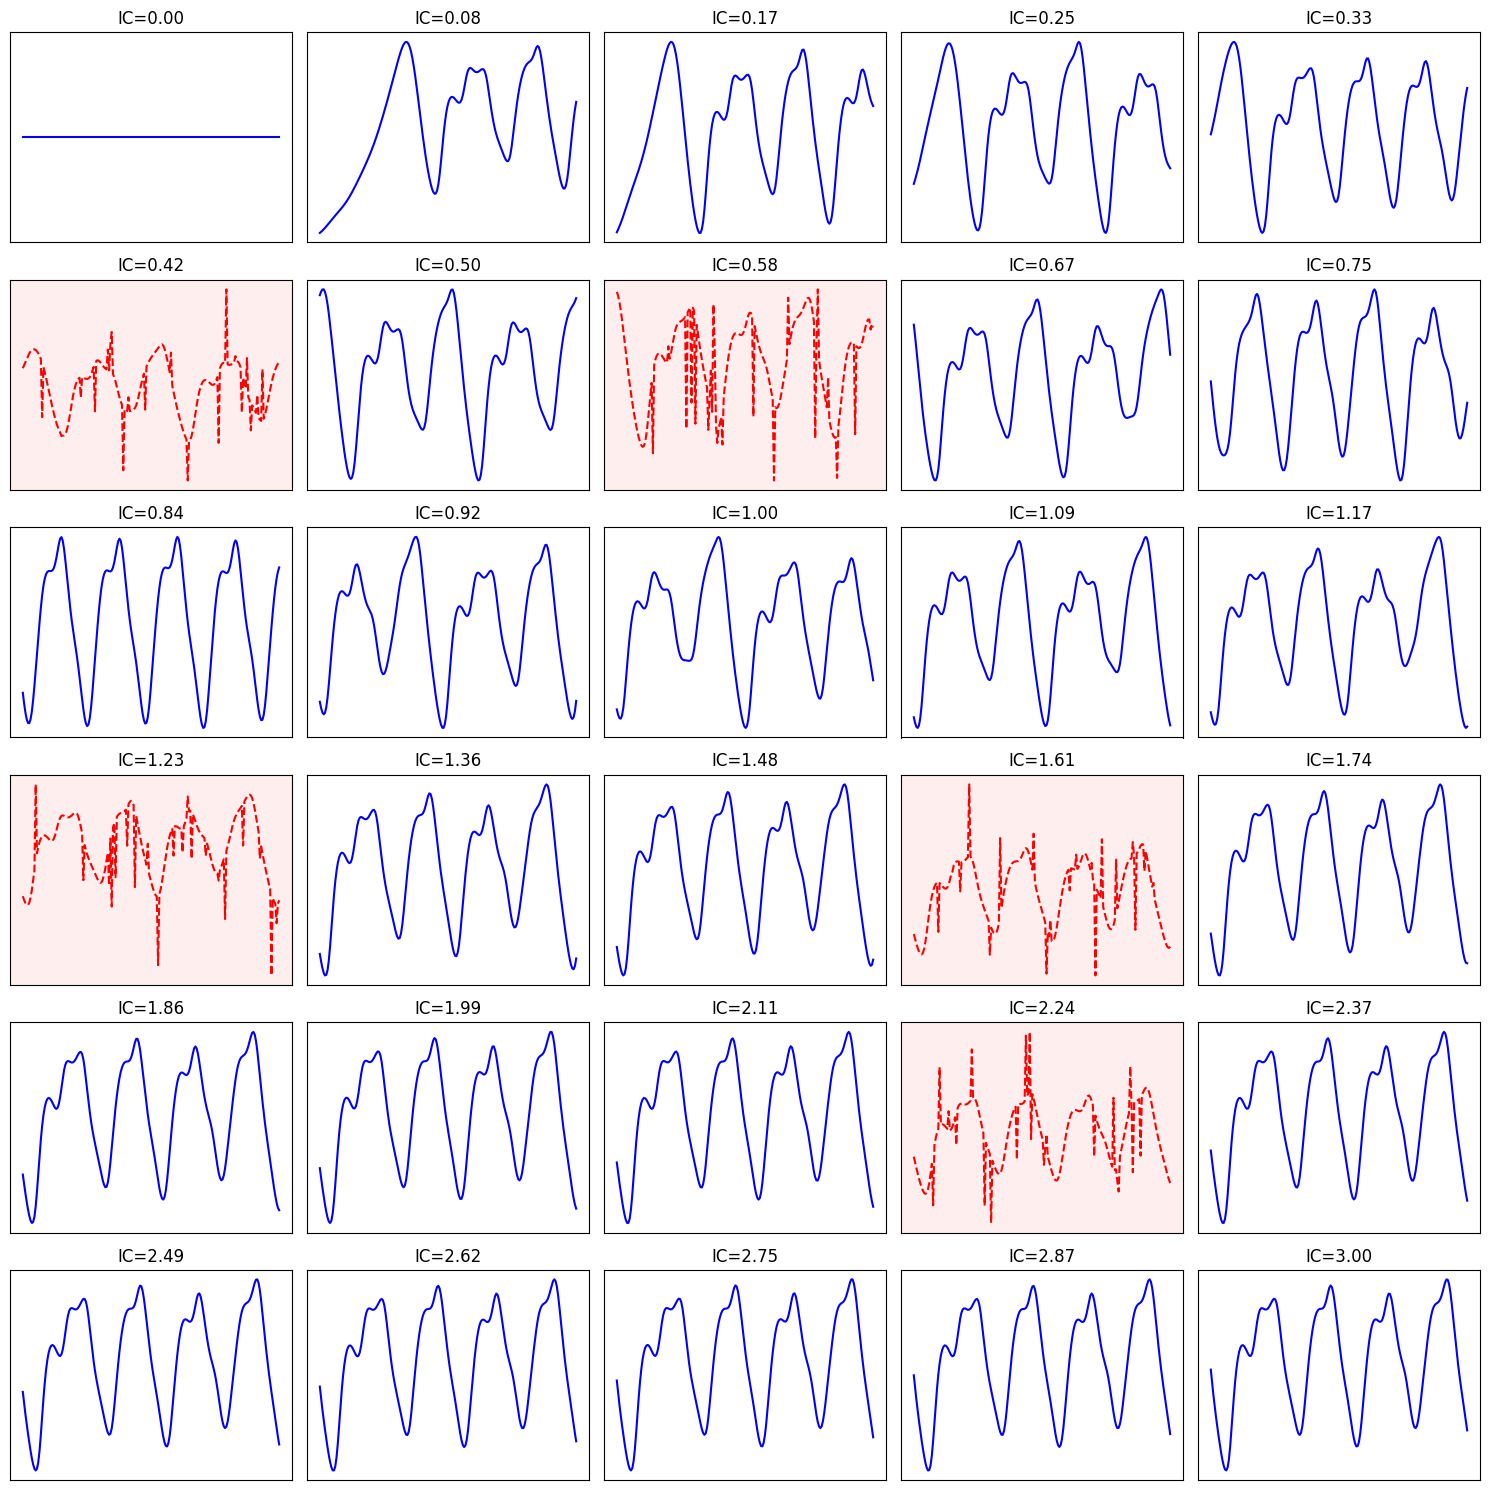

Pearson correlation: 0.9882
Spearman correlation: 0.9842
Spectral cosine similarity: 0.9985


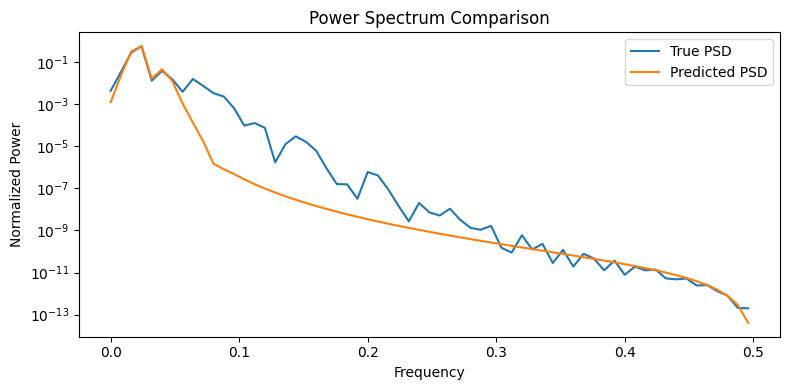

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import f, pearsonr, spearmanr
from scipy.signal import welch
from numpy.linalg import norm
from time import time
import math
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
import random
import torch

# --- Fix seeds for reproducibility ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1])
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Insert anomalies ---
def insert_anomalies(x, anomaly_rate=0.05, anomaly_scale=0.5):
    x_anom = x.copy()
    n_points = len(x)
    n_anomalies = int(n_points * anomaly_rate)
    anomaly_indices = np.random.choice(n_points, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        x_anom[idx] += np.random.uniform(-anomaly_scale, anomaly_scale)
    return x_anom

# --- Parameters ---
t_max = 275
start_time_step = 75
delta_t = 1
timesteps = np.arange(start_time_step, t_max, delta_t)
washout = 75

train_ics_left = np.linspace(0, 1.17, 15)
train_ics_right = np.linspace(1.23, 3, 15)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 1.2

# --- Generate training data with anomalies ---
X_list, y_list = [], []
anomalous_indices = [15, 5, 23, 7, 18]

for i, ic in enumerate(train_ics):
    x = mackey_glass(t_max=t_max, x0=ic)[start_time_step:]
    if i in anomalous_indices:
        x = insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7)
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# --- Test data (clean) ---
x_test = mackey_glass(t_max=t_max, x0=test_ic)[start_time_step:]
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- ReservoirPy ESN ---
start_time = time()
rpy.verbosity(0)
rpy.set_seed(42)

n_reservoir = 2500
reservoir = Reservoir(n_reservoir, lr=0.5, sr=0.9)
readout = Ridge(ridge=1e-7)
esn_model = reservoir >> readout

# Reshape for ReservoirPy (samples, time steps, features)
seq_len = len(timesteps)
X_rpy = X_scaled.reshape(len(train_ics), seq_len, 2)
y_rpy = y.reshape(len(train_ics), seq_len, 1)

X_test_rpy = X_test_scaled.reshape(1, seq_len, 2)  # add batch dim for test
y_test_rpy = y_test

# --- Fit and Predict ---
esn_model.fit(X_rpy, y_rpy)
y_pred = esn_model.run(X_test_rpy)
y_pred = y_pred.flatten()  # flatten to 1D for comparison

# --- Washout ---
y_true_w = y_test_rpy[washout:]
y_pred_w = y_pred[washout:]

# --- Errors and RMSE ---
errors = np.abs(y_pred_w - y_true_w)
rmse_window = np.sqrt((y_pred_w - y_true_w)**2)

def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

rmse = np.sqrt(mean_squared_error(y_true_w, y_pred_w))
r2 = r2_score(y_true_w, y_pred_w)
print("RMSE:", rmse)
print("R^2:", r2)

# --- Plot: True vs Predicted ---
plt.figure(figsize=(12, 5))
plt.plot(y_true_w, label='True Mackey-Glass (clean)')
plt.plot(y_pred_w, label='ESN Prediction')
plt.legend()
plt.title(f'Mackey-Glass Prediction (t=75→275), Washout={washout}')
plt.xlabel("Time step after washout")
plt.grid(True)
plt.show()

# --- Plot: Error metrics ---
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)")
plt.plot(smoothed_rmse, label="RMSE (Smoothed)")
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step after washout")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Divergence detection ---
threshold = 0.05
sustain_steps = 10
above_thresh = smoothed_error > threshold
sustained = np.convolve(above_thresh.astype(int), np.ones(sustain_steps, dtype=int), mode='valid') >= sustain_steps

if np.any(sustained):
    divergence_time = np.argmax(sustained) + sustain_steps - 1
    print(f"Prediction horizon at threshold {threshold} sustained for {sustain_steps} steps: {divergence_time} steps")
else:
    print(f"No sustained divergence above threshold {threshold} for {sustain_steps} steps detected.")

# --- F-test ---
n_samples = len(y_true_w)
k = X_test_scaled.shape[1]
F = (r2 / k) / ((1 - r2) / (n_samples - k - 1))
p_value = 1 - f.cdf(F, k, n_samples - k - 1)

print(f"\nF-statistic: {F:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("The model's predictions are statistically significant (p < 0.05).")
else:
    print("The model's predictions are NOT statistically significant (p ≥ 0.05).")

end_time = time()
print(f"\nTotal runtime: {end_time - start_time:.2f} seconds")

# --- Visualize Training Sequences ---
n_traj = len(y_list)
n_cols = 5
n_rows = math.ceil(n_traj / n_cols)

plt.figure(figsize=(n_cols * 3, n_rows * 2.5))
for i, x in enumerate(y_list):
    plt.subplot(n_rows, n_cols, i + 1)
    if i in anomalous_indices:
        plt.plot(x, 'r--', label=f"IC={train_ics[i]:.2f} (Anomalous)")
        plt.gca().set_facecolor("#ffeeee")
    else:
        plt.plot(x, 'b-', label=f"IC={train_ics[i]:.2f}")
    plt.title(f"IC={train_ics[i]:.2f}")
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

# --- Additional: Correlation Metrics ---
def correlation_metrics(y_true, y_pred):
    pearson_corr, _ = pearsonr(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)
    return pearson_corr, spearman_corr

pearson_corr, spearman_corr = correlation_metrics(y_true_w, y_pred_w)
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

# --- Additional: Spectral Similarity ---
def spectral_similarity(y_true, y_pred, fs=1.0):
    nperseg = min(128, len(y_true), len(y_pred))
    f_true, Pxx_true = welch(y_true, fs=fs, nperseg=nperseg)
    f_pred, Pxx_pred = welch(y_pred, fs=fs, nperseg=nperseg)

    # Normalize
    Pxx_true /= np.sum(Pxx_true)
    Pxx_pred /= np.sum(Pxx_pred)

    # Cosine similarity
    cosine_sim = np.dot(Pxx_true, Pxx_pred) / (norm(Pxx_true) * norm(Pxx_pred))
    return cosine_sim, f_true, Pxx_true, Pxx_pred

cos_sim, f, spec_true, spec_pred = spectral_similarity(y_true_w, y_pred_w)
print(f"Spectral cosine similarity: {cos_sim:.4f}")

# Plot spectra
plt.figure(figsize=(8,4))
plt.semilogy(f, spec_true, label="True PSD")
plt.semilogy(f, spec_pred, label="Predicted PSD")
plt.title("Power Spectrum Comparison")
plt.xlabel("Frequency")
plt.ylabel("Normalized Power")
plt.legend()
plt.tight_layout()
plt.show()
